<a href="https://colab.research.google.com/github/2024akcs4377f-spec/ML-assignment-2/blob/dataset-and-preprocessing/datacleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -q https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

In [ ]:
import pandas as pd

df = pd.read_csv('/content/diabetes.csv')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
import missingno as msno
from scipy import stats

In [ ]:
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print(f"\nDataset shape: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset shape: 768 rows, 9 columns


### Identify and handle missing values

In [ ]:
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("\nNumber of missing values found:")
    display(missing_values[missing_values > 0])

Missing values per column:
Series([], dtype: int64)
No missing values found in the dataset.


Missing values after replacing 0s with NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


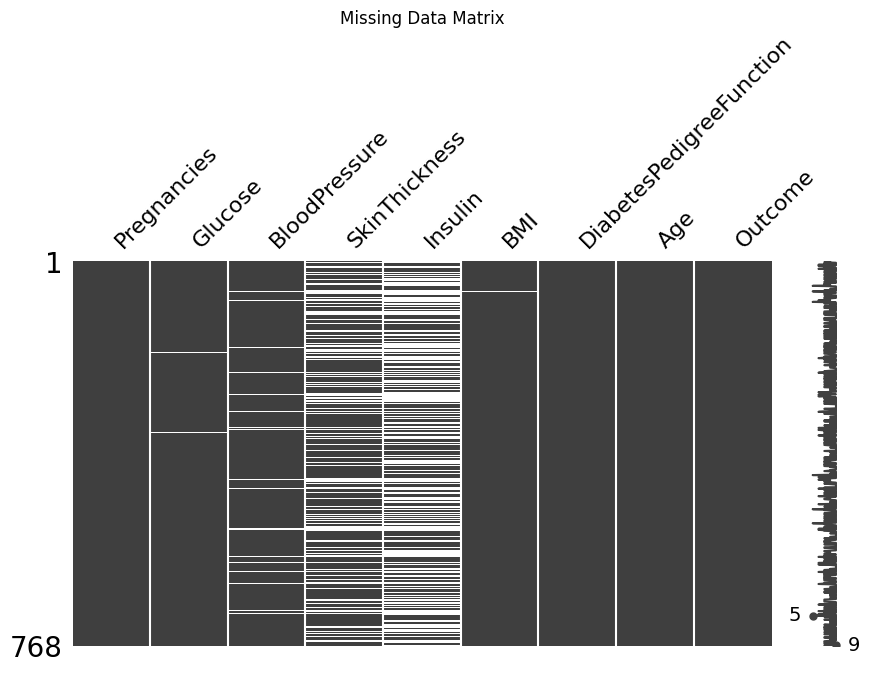

In [ ]:
columns_with_zeros_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0s with NaN in the identified columns
df[columns_with_zeros_as_missing] = df[columns_with_zeros_as_missing].replace(0, np.nan)

print("Missing values after replacing 0s with NaN:")
missing_values_after_replace = df.isnull().sum()
print(missing_values_after_replace[missing_values_after_replace > 0])

# Visualize missing data
msno.matrix(df, figsize=(10, 5))
plt.title('Missing Data Matrix')
plt.show()

In [ ]:
for column in columns_with_zeros_as_missing:
    if df[column].isnull().any(): # Check if there are any NaNs to impute
        median_value = df[column].median()
        df[column] = df[column].fillna(median_value) # Explicitly reassign the column

print("Missing values after imputation:")
missing_after_imputation = df.isnull().sum()
print(missing_after_imputation[missing_after_imputation > 0]) # Only print columns that still have NaNs

if missing_after_imputation.sum() == 0:
    print("Confirmed: All missing values have been imputed.")
else:
    print("Warning: Some missing values still exist. Please review the imputation logic.")

Missing values after imputation:
Series([], dtype: int64)
Confirmed: All missing values have been imputed.


## Step 6 — Perform Exploratory Data Analysis (EDA)

### Descriptive / Summary Statistics (After Preprocessing)

In [ ]:
print("Descriptive Statistics of the dataset after handling missing values:")
display(df.describe())

Descriptive Statistics of the dataset after handling missing values:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Univariate Analysis: Distribution of Features

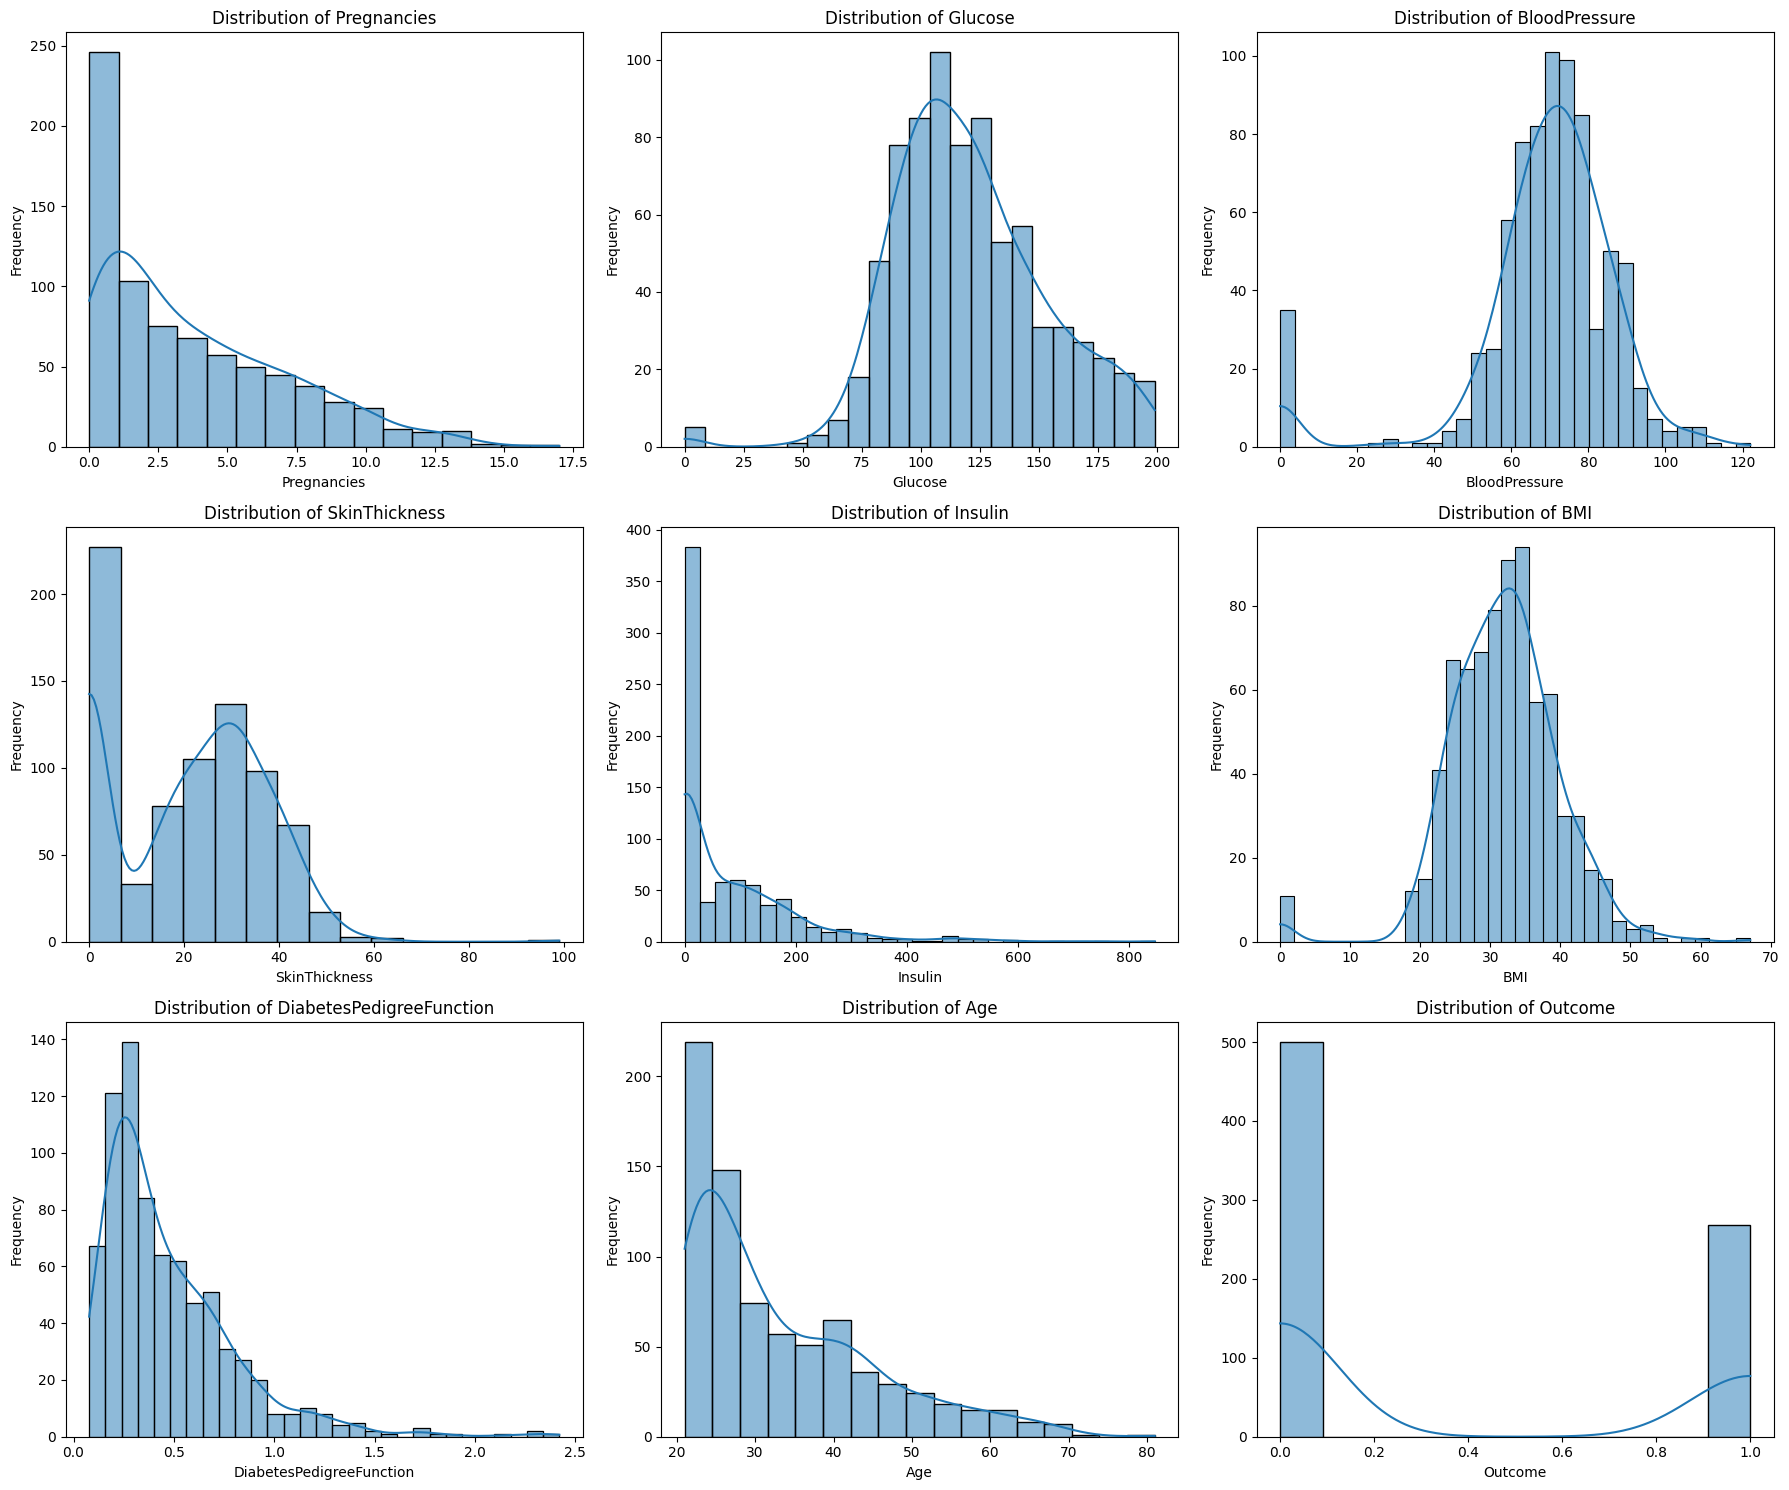

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, column in enumerate(df.columns):
    sns.histplot(df[column], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Univariate Analysis: Box Plots for Outlier Detection

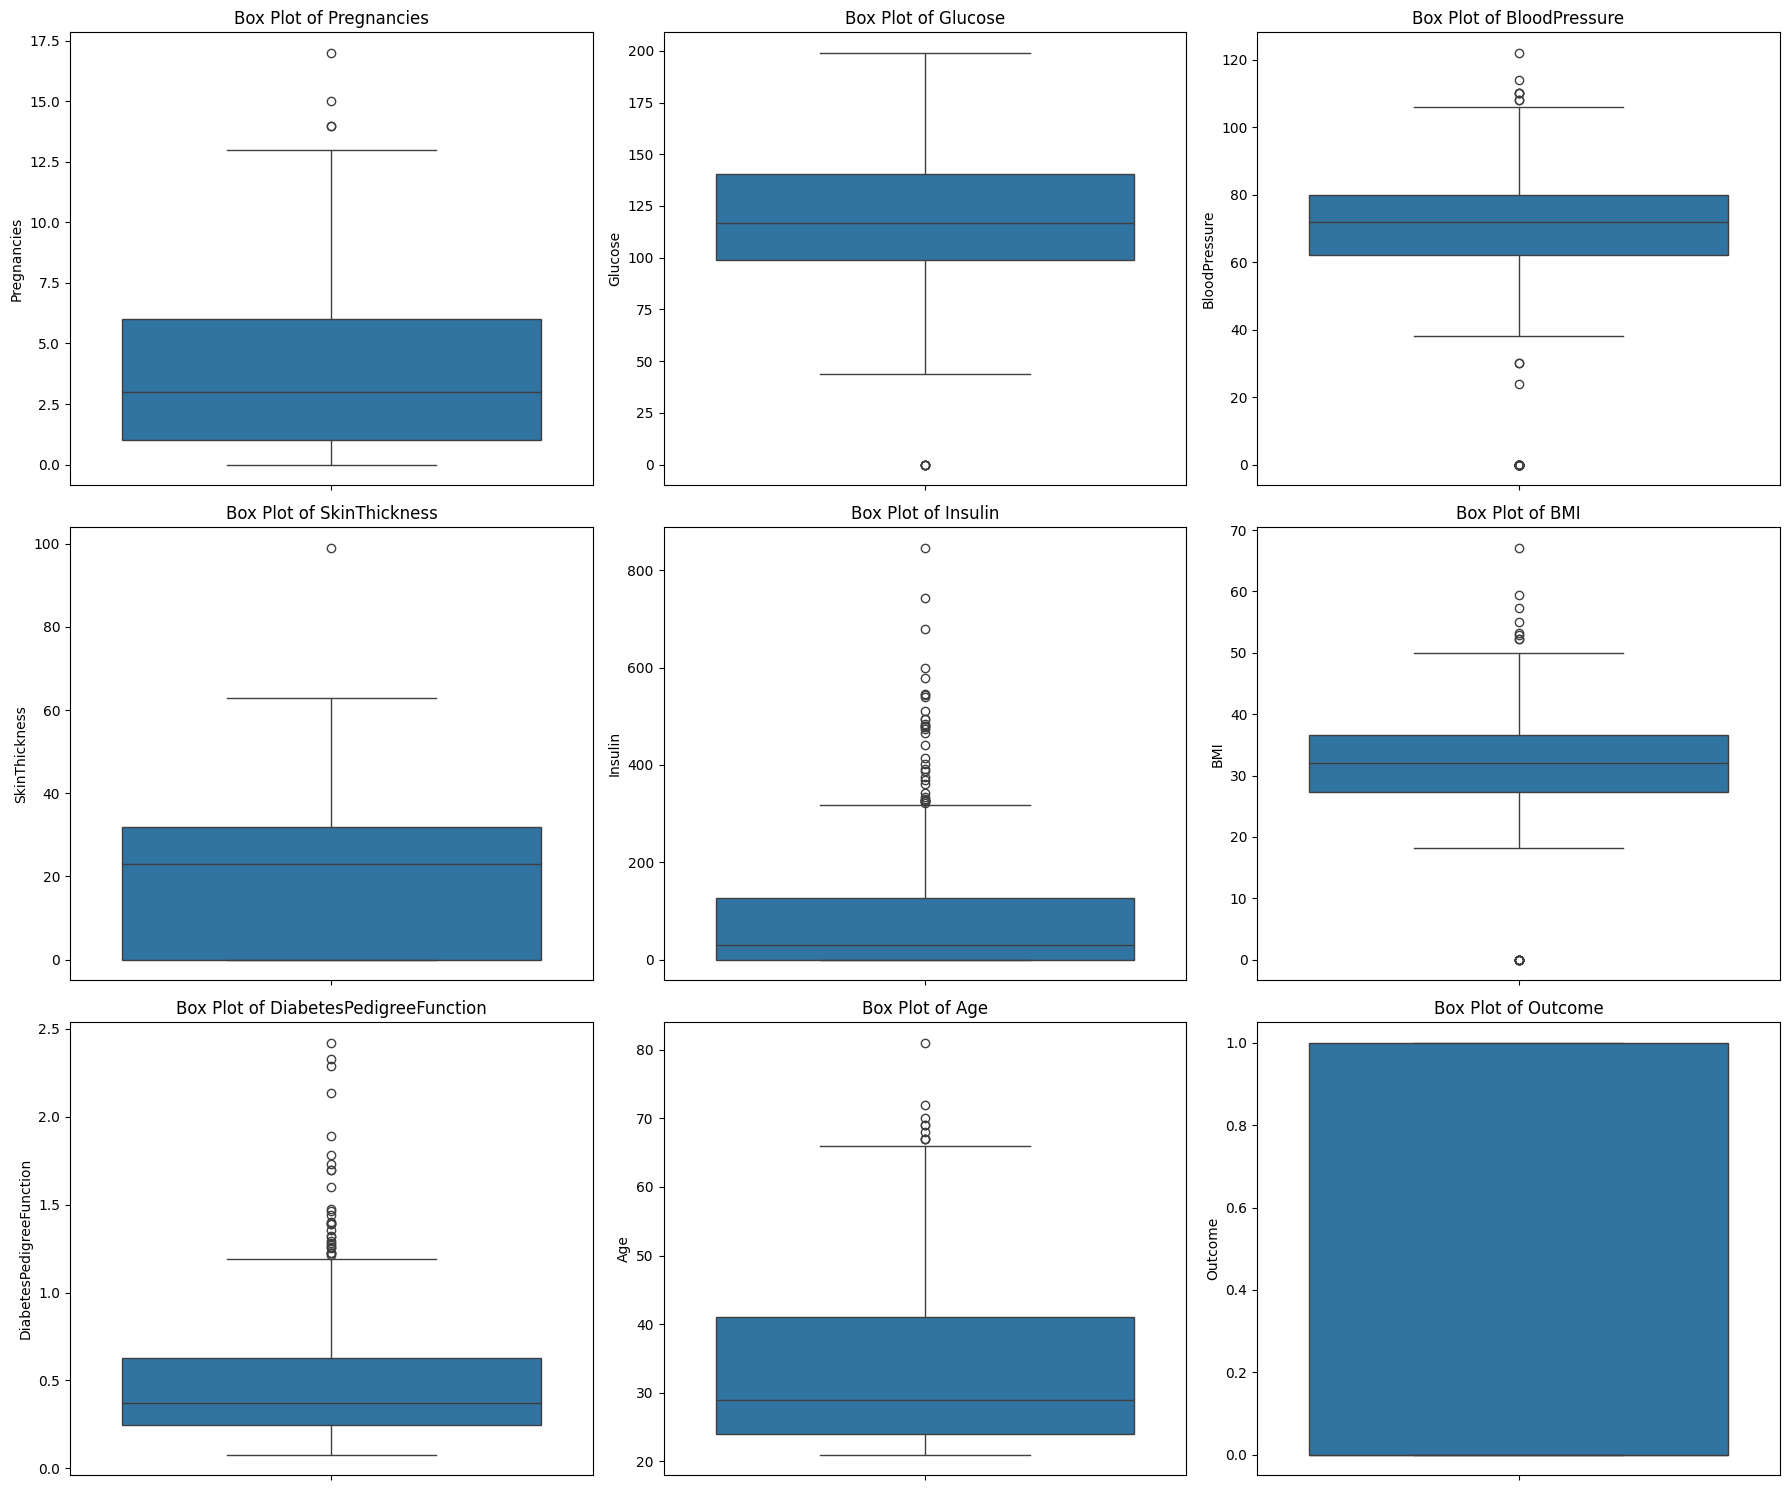

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, column in enumerate(df.columns):
    sns.boxplot(y=df[column], ax=axes[i])
    axes[i].set_title(f'Box Plot of {column}')
    axes[i].set_ylabel(column)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Bivariate / Multivariate Analysis: Correlation Heatmap

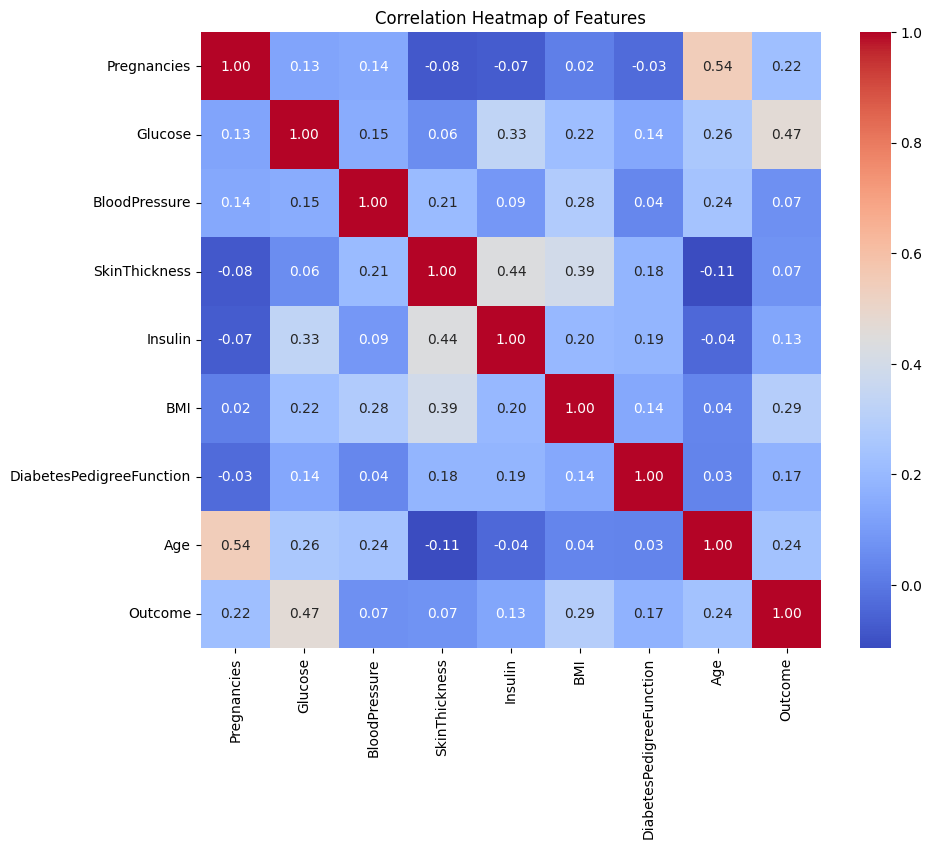

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

### Target Variable Analysis: Class Balance

/tmp/ipykernel_2497/1697849148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='viridis')


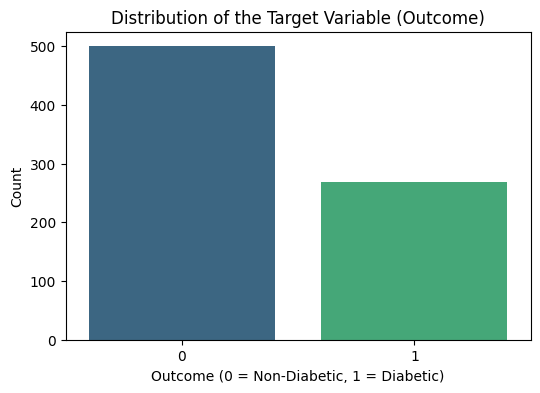

Percentage of Outcome classes:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='viridis')
plt.title('Distribution of the Target Variable (Outcome)')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

outcome_counts = df['Outcome'].value_counts(normalize=True) * 100
print("Percentage of Outcome classes:")
print(outcome_counts)

### Verify No Remaining Missing Values

In [ ]:
print("Checking for any remaining missing values:")
print(df.isnull().sum().sum())

if df.isnull().sum().sum() == 0:
    print("Confirmed: There are no remaining missing values in the dataset.")
else:
    print("Warning: Some missing values still exist. Review previous imputation steps.")

Checking for any remaining missing values:
0
Confirmed: There are no remaining missing values in the dataset.


### Identify and remove duplicate records

In [ ]:
print("Number of duplicate rows before removal:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Number of duplicate rows after removal:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0
Dataset shape after removing duplicates: (768, 9)


### Dividing the dataset into features (x) and target (y)

In [ ]:
y = df["Outcome"]
x = df.drop('Outcome', axis=1)

print("Shape of features (x):", x.shape)
print("Shape of target (y):", y.shape)

print("\nFirst 5 rows of features (x):")
display(x.head())

print("\nFirst 5 values of target (y):")
display(y.head())

Shape of features (x): (768, 8)
Shape of target (y): (768,)

First 5 rows of features (x):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33



First 5 values of target (y):


,Outcome
0,1
1,0
2,1
3,0
4,1


### Splitting the dataset into training and testing sets

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (537, 8)
Shape of x_test: (231, 8)
Shape of y_train: (537,)
Shape of y_test: (231,)


### Normalizing or standardizing numeric features

In [ ]:
# Before scaling, perform a final check and imputation for NaNs in x_train and x_test
print("Checking for NaNs in x_train before scaling:")
initial_nan_count_train = x_train.isnull().sum().sum()
if initial_nan_count_train > 0:
    print(f"Warning: {initial_nan_count_train} NaNs found in x_train. Imputing with column medians.")
    for col in x_train.columns:
        if x_train[col].isnull().any():
            median_val = x_train[col].median()
            x_train[col] = x_train[col].fillna(median_val)
else:
    print("No NaNs found in x_train.")

print("Checking for NaNs in x_test before scaling:")
initial_nan_count_test = x_test.isnull().sum().sum()
if initial_nan_count_test > 0:
    print(f"Warning: {initial_nan_count_test} NaNs found in x_test. Imputing with column medians.")
    for col in x_test.columns:
        if x_test[col].isnull().any():
            median_val = x_test[col].median()
            x_test[col] = x_test[col].fillna(median_val)
else:
    print("No NaNs found in x_test.")

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test = pd.DataFrame(x_test_scaled, columns=x_test.columns)

print("\nFirst 5 rows of scaled x_train:")
display(x_train.head())

print("\nFirst 5 rows of scaled x_test:")
display(x_test.head())

Checking for NaNs in x_train before scaling:
No NaNs found in x_train.
Checking for NaNs in x_test before scaling:
No NaNs found in x_test.

First 5 rows of scaled x_train:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.836294,-0.800051,-0.535764,-0.157146,-0.189732,-1.060153,-0.614216,-0.948610
1,0.390728,-0.490543,0.128044,0.553619,2.130203,0.646467,-0.909738,-0.434667
2,-1.143050,0.437979,-0.093226,1.393614,1.478536,1.355371,-0.306991,-0.777296
3,0.083972,0.314176,-0.093226,0.036699,0.748669,0.147609,-0.906812,-0.434667
4,-0.836294,-0.552445,-2.195284,1.135154,0.027491,1.486650,-0.839515,-0.006380



First 5 rows of scaled x_test:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.697483,-0.707199,-0.646399,0.812079,0.957202,0.265760,-0.116804,0.850192
1,-0.529539,-0.273888,0.293996,0.747464,-0.693688,0.488933,-0.941923,-1.034268
2,-0.529539,-0.397691,-0.314495,-1.320215,-0.693688,-0.154332,-0.912664,-1.034268
3,1.310994,-0.428642,0.570582,-1.320215,-0.693688,-0.968258,1.129653,0.079277
4,1.004239,0.468930,1.123756,-1.320215,-0.693688,-0.272482,-0.760514,1.449793


### Final Verification of Data Cleanliness

In [ ]:
print("Final check for NaNs in x_train:")
final_nan_count_train = x_train.isnull().sum().sum()
if final_nan_count_train == 0:
    print("Confirmed: x_train is free of NaN values.")
else:
    print(f"Warning: {final_nan_count_train} NaNs still found in x_train. Please review previous steps.")

print("\nFinal check for NaNs in x_test:")
final_nan_count_test = x_test.isnull().sum().sum()
if final_nan_count_test == 0:
    print("Confirmed: x_test is free of NaN values.")
else:
    print(f"Warning: {final_nan_count_test} NaNs still found in x_test. Please review previous steps.")

Final check for NaNs in x_train:
Confirmed: x_train is free of NaN values.

Final check for NaNs in x_test:
Confirmed: x_test is free of NaN values.
